# ERSST v6 monthly sea surface temperature

The Extended Reconstructed Sea Surface Temperature is NOAA NCEI's monthly
analysis of the global ocean's surface temperature on a 2 degree grid, rebuilt
from ship, buoy, and Argo float observations back to January 1850. It is the
record ENSO indices are computed from. NCEI publishes version 6, released in
December 2025, as one NetCDF4 file per month, and each file holds two global
grids: the temperature and its anomaly from the 1991-2020 climatology.

This walkthrough pulls the three months from May to July 2026, while an El Niño
was building in the tropical Pacific, and computes the Niño 3.4 index from them.
It needs `usdata[netcdf]` and matplotlib, and downloads three files of 168 kB
each in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.patches import Rectangle

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xarray {xr.__version__}")

Executed (UTC): 2026-09-28T19:54:38+00:00
usdata 0.32.0; xarray 2026.7.0


## Select

The manifest names a window and nothing else. ERSST files are whole global
grids with no server-side subsetting, so there is no box, variable, or
parameter to give; every calendar month the window touches is one file. May 1
to July 31 is May, June, and July. The newest month NCEI has published is
preliminary until the next monthly update rewrites it, so the window stops a
month short of it and the pins stay stable.

In [2]:
print(manifest.read_text())

name: ersst-el-nino-onset
sources:
  - dataset: noaa:ersst
    start: 2026-05-01
    end: 2026-07-31



## What arrives

The first pull downloads three files and writes `dataset.lock.json` beside the
manifest, pinning each checksum. The asset id is NCEI's filename, and the
asset's time is the whole calendar month.

In [3]:
result = pull(manifest)
for item in result.fetched:
    month = item.asset.time.start
    print(f"{item.asset.id}  {item.provenance.size:,} bytes  {month:%B %Y}")
first = result.fetched[0].provenance
print("Source:", first.source_url)
print("Retrieved (UTC):", first.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", first.checksum)

ersst.v6.202605.nc  168,286 bytes  May 2026
ersst.v6.202606.nc  168,286 bytes  June 2026
ersst.v6.202607.nc  168,286 bytes  July 2026
Source: https://www.ncei.noaa.gov/data/sea-surface-temperature-extended-reconstructed/v6/access/ersst.v6.202605.nc
Retrieved (UTC): 2026-09-28T19:54:39+00:00
Checksum: sha256:51ce0020c969aea0aaff92184e7ba7e93f532a4ad378e734a9be1ab0d0731de8


## Open

`open()` uses the netcdf extra and returns a loaded xarray Dataset. The grid is
`time × lev × lat × lon`, one month at one nominal depth, with latitudes from
88°S to 88°N and longitudes from 0 to 358°E, both every 2 degrees at cell
centres. `sst` is the monthly mean temperature and `ssta` its anomaly, both in
degrees Celsius; land and sea ice are missing. The file stamps its time at
mid-month.

In [4]:
months = [item.open().squeeze(["time", "lev"]) for item in result.fetched]
july = months[-1]
print("Variables:", {name: july[name].attrs["units"] for name in july.data_vars})
print("Grid:", dict(july.sizes), "· time", str(july.time.values)[:10])
print("Ocean cells:", int(july.sst.notnull().sum()), "of", july.sst.size)
print("Climatology:", july.attrs["climatology"])

Variables: {'sst': 'degree_C', 'ssta': 'degree_C'}
Grid: {'lat': 89, 'lon': 180} · time 2026-07-15
Ocean cells: 11074 of 16020
Climatology: Climatology is based on 1991-2020 SST of ERSSTv6.


The Niño 3.4 region is 5°S to 5°N and 170°W to 120°W, which is 190 to 240°E
on this grid. Its mean anomaly, averaged over three consecutive months, is how
ENSO strength is measured; five overlapping seasons at +0.5 °C or more make an
El Niño.

In [5]:
def nino34(grid: xr.Dataset) -> float:
    """The mean anomaly over the Niño 3.4 box, 5° S-5° N and 190-240° E."""
    return float(grid.ssta.sel(lat=slice(-5, 5), lon=slice(190, 240)).mean())


for item, grid in zip(result.fetched, months, strict=True):
    print(f"{item.asset.time.start:%B %Y}: Niño 3.4 anomaly {nino34(grid):+.2f} °C")
print(f"May-July mean: {np.mean([nino34(grid) for grid in months]):+.2f} °C")

May 2026: Niño 3.4 anomaly +0.85 °C
June 2026: Niño 3.4 anomaly +1.44 °C
July 2026: Niño 3.4 anomaly +1.76 °C
May-July mean: +1.35 °C


The index rose by almost a degree in two months. CPC's traditional Oceanic Niño
Index for May-July is +1.39 °C, also from ERSST v6, but on a 30-year base
period centred on each era rather than one fixed 1991-2020 base. NOAA's
official index since February 2026 is the Relative Oceanic Niño Index, which
first subtracts the mean anomaly of the whole tropics, 20°N to 20°S; it is
+0.97 °C for the same season, because the tropics are warm too.

## A first look

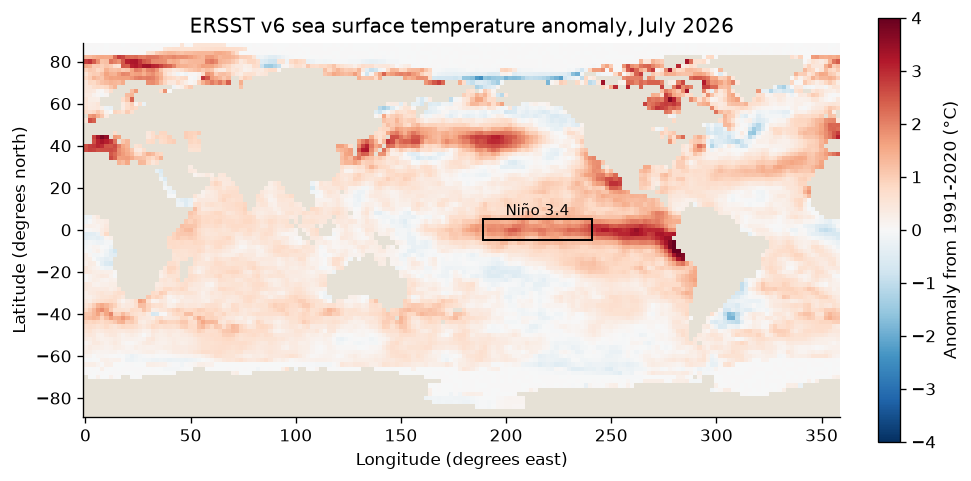

In [6]:
fig, ax = plt.subplots(layout="constrained")
ax.set_facecolor("#e6e1d6")
mesh = ax.pcolormesh(
    july.lon, july.lat, july.ssta, cmap="RdBu_r", vmin=-4, vmax=4, shading="nearest"
)
ax.add_patch(Rectangle((189, -5), 52, 10, fill=False, edgecolor="black", linewidth=1.2))
ax.text(215, 7, "Niño 3.4", ha="center", fontsize=9)
ax.set_aspect("equal")
ax.grid(False)
ax.set_xlabel("Longitude (degrees east)")
ax.set_ylabel("Latitude (degrees north)")
ax.set_title("ERSST v6 sea surface temperature anomaly, July 2026")
fig.colorbar(mesh, ax=ax, label="Anomaly from 1991-2020 (°C)", shrink=0.8)
plt.show()

In [7]:
tropics = july.ssta.sel(lat=slice(-10, 10))
peak = tropics.where(tropics == tropics.max(), drop=True)
lat, lon = float(peak.lat[0]), float(peak.lon[0])
where = f"{abs(lat):.0f}° {'S' if lat < 0 else 'N'}, {360 - lon:.0f}° W"
print(f"Warmest tropical anomaly: {float(tropics.max()):+.2f} °C at {where}")
weights = np.cos(np.radians(july.lat))
print(f"Global area-weighted mean anomaly: {float(july.ssta.weighted(weights).mean()):+.2f} °C")

Warmest tropical anomaly: +4.79 °C at 10° S, 78° W
Global area-weighted mean anomaly: +0.55 °C


The warm tongue runs west along the equator from the coast of South America,
strongest off Peru and Ecuador, where the anomaly reaches nearly 5 °C: the
pattern of an El Niño growing from the east. The whole ocean averages half a
degree above its 1991-2020 normal, so a basin-wide warm anomaly is not by
itself an El Niño; the index is the tropical Pacific relative to that normal.

## Pin and cite

`verify` checks the cached files against the lockfile's checksums. NCEI
rewrites the newest month once, at the next monthly update, and rewrote every
month from 2008 once in April 2026; a pin on a revised file reports it. Keep
the manifest and lockfile with your results. The citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:ersst
  Huang, B., X. Yin, T. Boyer, C. Liu, M. Menne, Y. D. Rao, T. Smith, R. Vose, and H.-M. Zhang, 2025: Extended Reconstructed Sea Surface Temperature Version 6 (ERSSTv6): Part I. An Artificial Neural Network Approach. Journal of Climate, 38, 1105-1121, doi:10.1175/JCLI-D-23-0707.1
  homepage: https://www.ncei.noaa.gov/products/extended-reconstructed-sst
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/products/extended-reconstructed-sst
  retrieved: 2026-09-28; 3 checksummed assets (504,858 bytes) pinned by usdata 0.32.0
  sources: 1


## What was awkward

- A Niño 3.4 value from these files is close to, not equal to, either index
  CPC publishes from them: `ssta` has one fixed base, 1991-2020, while ONI
  centres a base on each era and the official RONI also removes the tropical
  mean. Both indices are published only as CPC tables, not by NCEI.
- The file stamps each month at its 15th while the asset's time is the whole
  month, and a Dataset opened from each file carries a one-step `time` and a
  one-level `lev`, so combining months starts with `squeeze`.
- Longitudes run 0 to 360, so the Niño 3.4 box's western edge, 170°W, is 190
  on this grid, and a map of the Pacific has to be drawn in those units.
- The newest month is preliminary and nothing in the file or the listing says
  so; the monthly rewrite shows only in the directory's modified stamps.
- Area weighting is left to the caller: a plain mean over the grid overweights
  high latitudes, where cells are smaller.